# Agricultural Burning Detection in Heilongjiang

Open biomass burning is an important environmental issue in agricultural regions. In China, crop stover from maize and wheat can be difficult to reuse quickly, especially where the next planting cycle leaves little time for field preparation. Burning residue is a fast and low-cost option for some farmers, but it releases fine particles, carbon monoxide, nitrogen oxides and other pollutants. These emissions can contribute to seasonal haze, reduce visibility and increase health risks for nearby and downwind populations.

Although open burning is restricted by policy, enforcement is difficult because fires may be short-lived, spatially scattered and sometimes timed to avoid detection. Remote sensing therefore provides an important monitoring tool. Satellite active-fire products can record the location, timing and fire radiative power of burning events, while crop phenology data can help identify whether a fire occurs after the local harvest period.

Heilongjiang is a useful case study because it is one of China's major grain-producing provinces and has large areas of mechanised grain production. A recent remote-sensing study of main grain crops in Heilongjiang from 2019 to 2023 shows that maize, rice and soybean fields form clear and persistent spatial patterns across the province (Huang et al., 2026). This supports the use of crop maps as important context when interpreting fire detections. Its cold climate and clear crop calendar also make seasonal fire patterns especially relevant. If satellite fire detections can be linked to crop maturity dates, they can provide a practical way to screen for possible agricultural burning across a large area.

This notebook uses satellite fire detections to explore whether some fires are likely to be linked to post-harvest agricultural burning. The implemented classification combines MODIS active fire points, China county boundaries, and annual crop maturity rasters for maize and wheat. A fire is treated as part of a narrow post-maturity screening subset when it falls on a valid maize or wheat maturity pixel and occurs within 30 days after the mapped maturity date. A small Fengyun satellite straw-burning reference dataset is used as an external validation check for the MODIS fire detections and the maize/wheat post-maturity screening rule.

The aim is not to prove the cause of every fire. Instead, the workflow builds a transparent screening method that separates a small, interpretable subset of crop-related fires from the much larger population of all detected fires. The results can support exploratory spatial analysis, temporal comparison and later validation with policy, land-use, meteorological or pollution records.


## 1. Setup and Data Paths

In [281]:
from pathlib import Path
from datetime import datetime, timedelta
import glob
import os

import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde

matplotlib.rcParams["axes.unicode_minus"] = False

# Resolve paths so the notebook can run from the project root or notebooks folder.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_SAMPLE = PROJECT_ROOT / "data" / "sample"
DATA_EXTERNAL = PROJECT_ROOT / "data" / "external"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
PLOT_SAMPLE_SIZE = 30000
RANDOM_SEED = 42

# Keep large boundary and derived fire-point files under data/external.
county_shp_path = DATA_EXTERNAL / "CHN_County.shp"
modis_hlj_sample_path = DATA_SAMPLE / "modis_hlj_2010.geojson"
modis_hlj_external_path = DATA_EXTERNAL / "modis_hlj.geojson"
fy_excel_path = DATA_SAMPLE / "straw burning fire point monitoring data.xlsx"

print("Project root:", PROJECT_ROOT)
print("data/sample exists:", DATA_SAMPLE.exists())
print("data/external exists:", DATA_EXTERNAL.exists())
print("CHN_County.shp exists:", county_shp_path.exists())
print("Heilongjiang sample GeoJSON exists:", modis_hlj_sample_path.exists())
print("geopandas:", gpd.__version__)
print("rasterio:", rasterio.__version__)


Project root: C:\Users\zilin\Documents\Codex\2026-07-05\w\outputs\coursework-portfolio-cleaned\projects\agricultural-burning-remote-sensing
data/sample exists: True
data/external exists: True
CHN_County.shp exists: True
Heilongjiang sample GeoJSON exists: True
geopandas: 1.1.2
rasterio: 1.4.3


## 2. MODIS Fire Detections

The MODIS files contain active-fire detections for China from 2010 to 2019. Each record includes location, acquisition date and time, and fire radiative power (FRP), which is used later as a proxy for fire intensity. The first step reads all available annual CSV files, removes records with missing location or fire intensity values, and converts the table into a GeoDataFrame.


In [283]:
csv_files = sorted(glob.glob(str(DATA_SAMPLE / "modis_*_China.csv")))
print(f"MODIS CSV files found: {len(csv_files)}")

if not csv_files:
    raise FileNotFoundError("No MODIS CSV files were found in data/sample.")

# Combine annual MODIS files into one national fire-detection table.
modis_df = pd.concat((pd.read_csv(file) for file in csv_files), ignore_index=True)
modis_df = modis_df.dropna(subset=["latitude", "longitude", "acq_date", "frp"])
modis_df["acq_date"] = pd.to_datetime(modis_df["acq_date"])

# Remove obvious out-of-domain coordinates before spatial processing.
modis_df = modis_df[
    modis_df["latitude"].between(18, 54) &
    modis_df["longitude"].between(73, 135)
].copy()

modis_gdf = gpd.GeoDataFrame(
    modis_df,
    geometry=gpd.points_from_xy(modis_df.longitude, modis_df.latitude),
    crs="EPSG:4326",
)

print(f"Cleaned MODIS fire detections: {len(modis_gdf):,}")
print(f"Date range: {modis_gdf['acq_date'].min().date()} to {modis_gdf['acq_date'].max().date()}")
modis_gdf[["latitude", "longitude", "acq_date", "frp"]].head()


MODIS CSV files found: 10
Cleaned MODIS fire detections: 1,073,117
Date range: 2010-01-01 to 2019-12-31


,latitude,longitude,acq_date,frp
0,30.8759,120.1314,2010-01-01,7.5
1,28.6087,121.4316,2010-01-01,10.1
2,27.0163,102.2247,2010-01-01,14.5
3,26.5719,101.6699,2010-01-01,7.1
4,27.8552,100.6149,2010-01-01,10.5


## 3. Boundary Filtering

The analysis focuses on Heilongjiang. When the China county shapefile is present, the notebook selects counties where `NAME_1` is Heilongjiang and performs a spatial join. If the shapefile is not available, it loads the prepared Heilongjiang sample GeoJSON instead.


In [285]:
def select_heilongjiang_boundary(county_gdf):
    """Return Heilongjiang boundary rows from the China county shapefile."""
    if "NAME_1" in county_gdf.columns:
        boundary = county_gdf[
            county_gdf["NAME_1"].astype(str).str.contains("Heilongjiang", case=False, na=False)
        ]
        if not boundary.empty:
            return boundary

    text_cols = [col for col in county_gdf.columns if col != county_gdf.geometry.name]
    mask = pd.Series(False, index=county_gdf.index)
    for col in text_cols:
        values = county_gdf[col].astype(str)
        mask = mask | values.str.contains("Heilongjiang", case=False, na=False)
    return county_gdf[mask]


def load_hlj_boundary():
    """Load the optional Heilongjiang county boundary."""
    if not county_shp_path.exists():
        return None
    county_gdf = gpd.read_file(county_shp_path, engine="fiona")
    boundary = select_heilongjiang_boundary(county_gdf)
    return boundary if not boundary.empty else None


# Prefer the county boundary when available; otherwise use prepared fallback files.
if county_shp_path.exists():
    hlj_boundary = load_hlj_boundary()
    if hlj_boundary is None:
        raise ValueError("CHN_County.shp was found, but no Heilongjiang boundary rows were identified.")

    # Spatially filter national fire detections to Heilongjiang counties.
    modis_hlj = gpd.sjoin(modis_gdf, hlj_boundary, how="inner", predicate="intersects")
    modis_hlj = modis_hlj.drop(columns=[col for col in ["index_right"] if col in modis_hlj.columns])
    modis_hlj["acq_date"] = pd.to_datetime(modis_hlj["acq_date"])
    print(f"Heilongjiang county boundary rows: {len(hlj_boundary):,}")
    print(f"Heilongjiang MODIS fire detections: {len(modis_hlj):,}")
elif modis_hlj_external_path.exists():
    modis_hlj = gpd.read_file(modis_hlj_external_path)
    modis_hlj["acq_date"] = pd.to_datetime(modis_hlj["acq_date"])
    hlj_boundary = None
    print(f"Loaded external Heilongjiang fire detections: {len(modis_hlj):,}")
elif modis_hlj_sample_path.exists():
    modis_hlj = gpd.read_file(modis_hlj_sample_path)
    modis_hlj["acq_date"] = pd.to_datetime(modis_hlj["acq_date"])
    hlj_boundary = None
    print(f"Loaded sample Heilongjiang fire detections: {len(modis_hlj):,}")
else:
    raise FileNotFoundError("No Heilongjiang boundary or fire-point sample file was found.")

modis_hlj["year"] = modis_hlj["acq_date"].dt.year
modis_hlj["month"] = modis_hlj["acq_date"].dt.month
print(f"Years covered: {modis_hlj['year'].min()}-{modis_hlj['year'].max()}")


Heilongjiang county boundary rows: 128
Heilongjiang MODIS fire detections: 206,929
Years covered: 2010-2019


The boundary-filtered dataset is the main analytical table used below. In the full run, the workflow keeps 206,929 MODIS fire detections inside Heilongjiang from the 1,073,117 cleaned detections across China. This step is important because national fire detections include very different climates, land uses and burning practices. Restricting the analysis to Heilongjiang makes the later crop-maturity interpretation more meaningful.


## 4. Exploratory Fire Patterns

The first set of charts describes the seasonal and spatial distribution of fire detections. Monthly counts use the full dataset. The maps use a fixed random sample of points so that the figures remain readable and the notebook runs reliably with full boundary-filtered data.


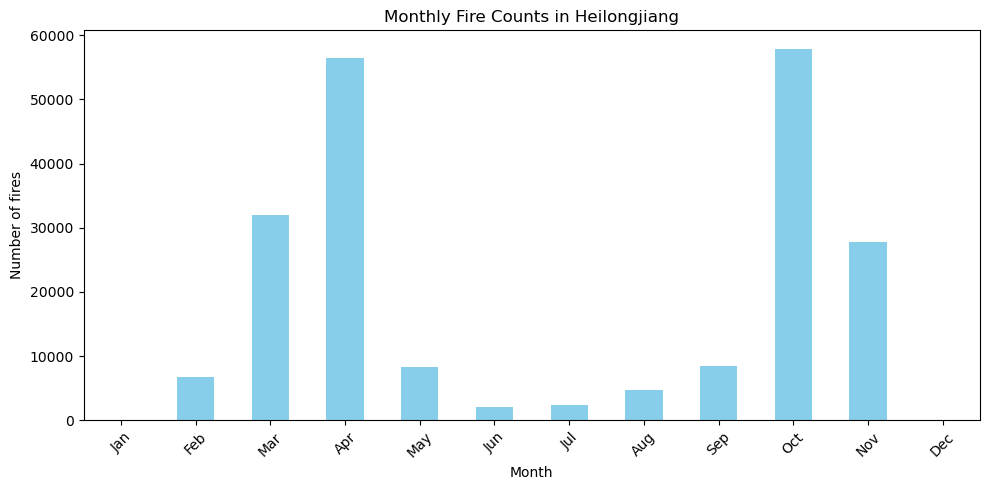

Spatial figures use 30,000 sampled points from 206,929 total detections.


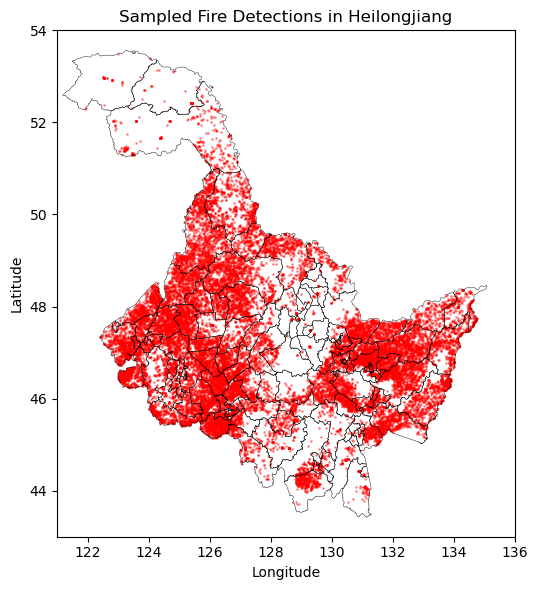

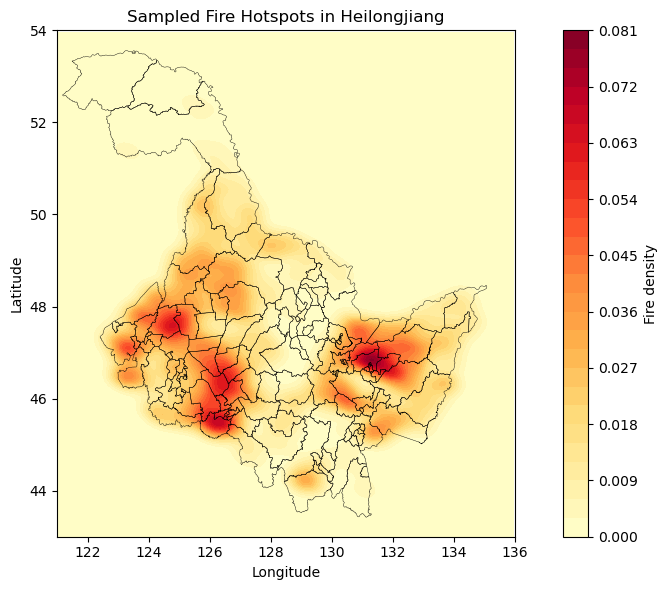

In [288]:
# Start with a seasonal overview of all Heilongjiang fire detections.
monthly_fire_counts = modis_hlj.groupby("month").size().reindex(range(1, 13), fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
monthly_fire_counts.plot(kind="bar", color="skyblue", ax=ax)
ax.set_title("Monthly Fire Counts in Heilongjiang")
ax.set_xlabel("Month")
ax.set_ylabel("Number of fires")
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], rotation=45)
plt.tight_layout()
plt.show()

# Use a fixed sample for maps so plotting remains readable and reproducible.
plot_sample = modis_hlj.sample(
    n=min(PLOT_SAMPLE_SIZE, len(modis_hlj)),
    random_state=RANDOM_SEED,
) if len(modis_hlj) > PLOT_SAMPLE_SIZE else modis_hlj

print(f"Spatial figures use {len(plot_sample):,} sampled points from {len(modis_hlj):,} total detections.")

xlim = (121, 136)
ylim = (43, 54)

fig, ax = plt.subplots(figsize=(10, 6))
plot_sample.plot(ax=ax, color="red", markersize=1, alpha=0.35)
if hlj_boundary is not None:
    hlj_boundary.boundary.plot(ax=ax, color="black", linewidth=0.3)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_title("Sampled Fire Detections in Heilongjiang")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

x = plot_sample["longitude"].astype(float)
y = plot_sample["latitude"].astype(float)
kde = gaussian_kde([x, y], bw_method=0.1)
x_grid, y_grid = np.mgrid[121:136:0.05, 43:54:0.05]
positions = np.vstack([x_grid.ravel(), y_grid.ravel()])
density = kde(positions).reshape(x_grid.shape)

fig, ax = plt.subplots(figsize=(10, 6))
c = ax.contourf(x_grid, y_grid, density, levels=30, cmap="YlOrRd")
if hlj_boundary is not None:
    hlj_boundary.boundary.plot(ax=ax, color="black", linewidth=0.3)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
plt.colorbar(c, ax=ax, label="Fire density")
ax.set_title("Sampled Fire Hotspots in Heilongjiang")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()


The exploratory charts show that fire activity is strongly seasonal and spatially clustered. This matters because agricultural burning is expected to appear in particular periods after crop maturity, not as a uniform pattern through the year. The sampled maps are used only for visual clarity; all counts and classifications in the following sections are still calculated from the full boundary-filtered dataset.


## 5. Crop Maturity Data Integration

Maize and wheat maturity rasters are used to identify whether each fire falls on a valid crop-maturity pixel. The notebook reads the raster for the matching year, samples the raster value at each fire point, and records whether the point falls inside a valid maize or wheat maturity surface. Valid maturity values are restricted to day-of-year values from 1 to 366, so raster NoData and background values are not treated as crop presence. The crop-mapping results reported by Huang et al. (2026) support the broader assumption that Heilongjiang's grain crops have strong spatial structure, so crop-location information is necessary before attributing fire detections to agricultural burning.  

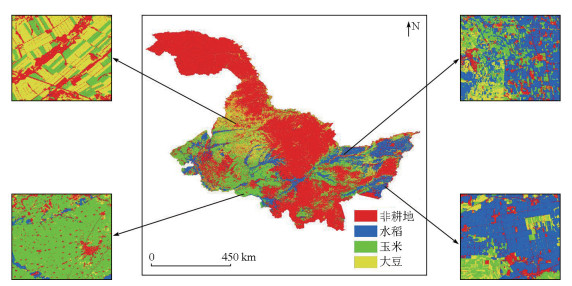 

Crop classification results of Heilongjiang Province in 2019 Source: Huang et al. (2026)

In [318]:
def crop_raster_path(crop, year):
    return DATA_SAMPLE / f"Heilongjiang_{crop}_MA_{year}.tif"


def match_crop_raster(fire_gdf, crop_tif_path):
    """Return 1 when a fire point overlaps a valid crop maturity DOY value."""
    with rasterio.open(crop_tif_path) as crop_ras:
        fire_crs = fire_gdf.to_crs(crop_ras.crs)
        fire_coords = [(geom.x, geom.y) for geom in fire_crs.geometry]
        values = np.array([val[0] for val in crop_ras.sample(fire_coords)], dtype=float)
    return np.where((values >= 1) & (values <= 366), 1, 0)


# Binary flags record whether a fire falls on a valid maturity pixel.
modis_hlj["in_maize"] = 0
modis_hlj["in_wheat"] = 0

for year in sorted(modis_hlj["year"].unique()):
    maize_path = crop_raster_path("Maize", year)
    wheat_path = crop_raster_path("Wheat", year)
    if not maize_path.exists() or not wheat_path.exists():
        print(f"Skipping crop matching for {year}: raster file missing.")
        continue

    year_mask = modis_hlj["year"] == year
    fires_this_year = modis_hlj.loc[year_mask]
    if fires_this_year.empty:
        continue

    # Sample the matching year's crop rasters at fire-point locations.
    modis_hlj.loc[year_mask, "in_maize"] = match_crop_raster(fires_this_year, maize_path)
    modis_hlj.loc[year_mask, "in_wheat"] = match_crop_raster(fires_this_year, wheat_path)

modis_hlj["crop_type"] = "Non-crop or unmatched"
modis_hlj.loc[modis_hlj["in_maize"] == 1, "crop_type"] = "Maize"
modis_hlj.loc[modis_hlj["in_wheat"] == 1, "crop_type"] = "Wheat"

crop_fire_mask = (modis_hlj["in_maize"] == 1) | (modis_hlj["in_wheat"] == 1)
print(f"Fires on valid maize maturity pixels: {int(modis_hlj['in_maize'].sum()):,}")
print(f"Fires on valid wheat maturity pixels: {int(modis_hlj['in_wheat'].sum()):,}")
print(f"Unique fires on maize/wheat maturity pixels: {int(crop_fire_mask.sum()):,}")


Fires on valid maize maturity pixels: 45,453
Fires on valid wheat maturity pixels: 913
Unique fires on maize/wheat maturity pixels: 46,366


## 6. Agricultural Burning Screening

A fire is selected by the post-maturity screen when it occurs on a valid maize or wheat maturity pixel within 30 days after the mapped maturity date at that location. Invalid raster values are treated as missing and are not counted as post-maturity fires.


In [293]:
def clean_maturity_doy(values):
    """Return numeric day-of-year values, with invalid raster values set to NaN."""
    cleaned = pd.to_numeric(values, errors="coerce").astype(float)
    cleaned[(cleaned < 1) | (cleaned > 366)] = np.nan
    return cleaned


def get_crop_mature_doy(fire_gdf, crop_tif_path):
    """Sample crop maturity day-of-year values at fire locations."""
    with rasterio.open(crop_tif_path) as crop_ras:
        fire_crs = fire_gdf.to_crs(crop_ras.crs)
        fire_coords = [(geom.x, geom.y) for geom in fire_crs.geometry]
        doy_values = np.array([val[0] for val in crop_ras.sample(fire_coords)], dtype=float)
    doy_values[doy_values == 0] = np.nan
    return doy_values


def is_after_maturity(fire_date, crop_mature_doy, window_days=30):
    """Return True when a fire occurs within the post-maturity window."""
    if pd.isna(crop_mature_doy) or crop_mature_doy < 1 or crop_mature_doy > 366:
        return False
    mature_date = datetime(fire_date.year, 1, 1) + timedelta(days=int(crop_mature_doy) - 1)
    return mature_date <= fire_date <= mature_date + timedelta(days=window_days)


# Store maturity DOY values and post-maturity flags for each fire point.
modis_hlj["maize_mature_doy"] = np.nan
modis_hlj["wheat_mature_doy"] = np.nan
modis_hlj["in_maize_after"] = False
modis_hlj["in_wheat_after"] = False

for year in sorted(modis_hlj["year"].unique()):
    maize_path = crop_raster_path("Maize", year)
    wheat_path = crop_raster_path("Wheat", year)
    if not maize_path.exists() or not wheat_path.exists():
        print(f"Skipping maturity matching for {year}: raster file missing.")
        continue

    year_mask = modis_hlj["year"] == year
    fires_this_year = modis_hlj.loc[year_mask]
    if fires_this_year.empty:
        continue

    maize_doy = clean_maturity_doy(pd.Series(get_crop_mature_doy(fires_this_year, maize_path), index=fires_this_year.index))
    wheat_doy = clean_maturity_doy(pd.Series(get_crop_mature_doy(fires_this_year, wheat_path), index=fires_this_year.index))

    modis_hlj.loc[year_mask, "maize_mature_doy"] = maize_doy
    modis_hlj.loc[year_mask, "wheat_mature_doy"] = wheat_doy

modis_hlj["in_maize_after"] = modis_hlj.apply(
    lambda row: is_after_maturity(row["acq_date"], row["maize_mature_doy"]),
    axis=1,
)
modis_hlj["in_wheat_after"] = modis_hlj.apply(
    lambda row: is_after_maturity(row["acq_date"], row["wheat_mature_doy"]),
    axis=1,
)

# This mask is the main rule-based agricultural-burning classification.
post_maturity_mask = modis_hlj["in_maize_after"] | modis_hlj["in_wheat_after"]
print(f"Maize post-maturity fires: {int(modis_hlj['in_maize_after'].sum()):,}")
print(f"Wheat post-maturity fires: {int(modis_hlj['in_wheat_after'].sum()):,}")
print(f"Unique post-maturity crop fires: {int(post_maturity_mask.sum()):,}")
print(f"All Heilongjiang fires: {len(modis_hlj):,}")
print(f"Post-maturity share: {(post_maturity_mask.sum() / len(modis_hlj)) * 100:.2f}%")


Maize post-maturity fires: 3,993
Wheat post-maturity fires: 95
Unique post-maturity crop fires: 4,088
All Heilongjiang fires: 206,929
Post-maturity share: 1.98%


The post-maturity rule is intentionally narrow. It does not claim to detect all agricultural burning; it only identifies MODIS fires that fall on valid maize or wheat maturity pixels within a fixed post-maturity window.

In the corrected full run, 46,366 MODIS detections fall on valid maize or wheat maturity pixels, and 4,088 fires pass the post-maturity screen. This is only 1.98% of all Heilongjiang MODIS fires. The small share is plausible because the original fire dataset includes many non-agricultural fires, fires outside the maize/wheat maturity surfaces, and fires outside the 30-day post-maturity window.


## 7. FY-Satellite Validation

The Fengyun straw-burning monitoring spreadsheet is used as an external reference dataset for the period it covers. To keep the validation temporally consistent, both FY points and MODIS fire detections are restricted to 1 August 2016 to 28 February 2017 before matching.

The workflow first filters FY points to Heilongjiang and samples the corresponding 2016 or 2017 maize/wheat maturity rasters. It then searches for the nearest MODIS fire detection from the same validation period within 3 km and within one day before or after the FY date. The matched MODIS point is compared with the current maize/wheat post-maturity screening rule.


,Metric,Count,Reference group,Share (%)
0,FY reference points in validation period,2583,FY validation-period points,100.00
1,FY reference points in Heilongjiang,1497,All FY points,57.96
2,FY points matched to same-period MODIS within ...,1493,FY points in Heilongjiang,99.73
3,Matched FY points linked to current maize/whea...,19,FY-MODIS matched points,1.27
4,FY points directly on valid maize/wheat maturi...,540,FY points in Heilongjiang,36.07
5,FY points directly passing maize/wheat post-ma...,20,FY points in Heilongjiang,1.34


FY-MODIS matching distance summary, metres
count    1493.000000
mean       47.864293
std        98.909193
min         0.000000
25%        26.975398
50%        39.355072
75%        54.149347
max      2565.408541
Name: distance_m, dtype: float64


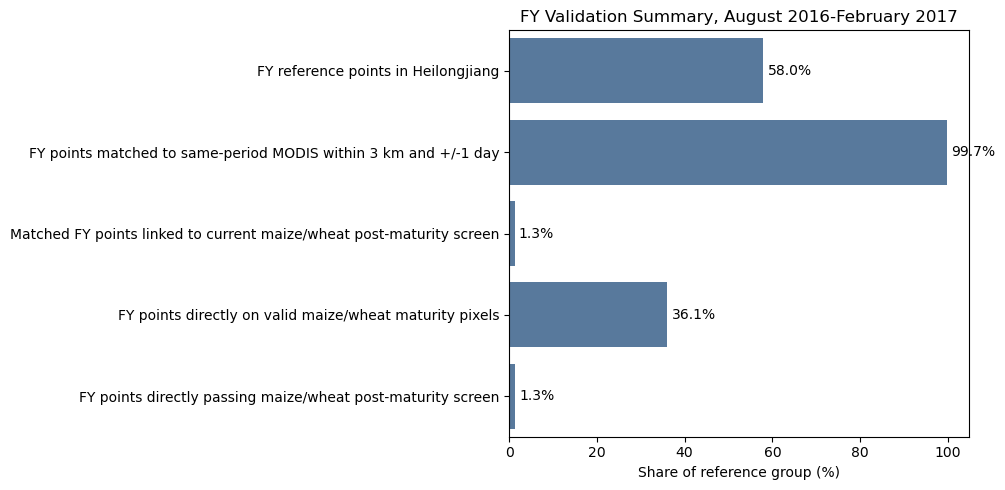

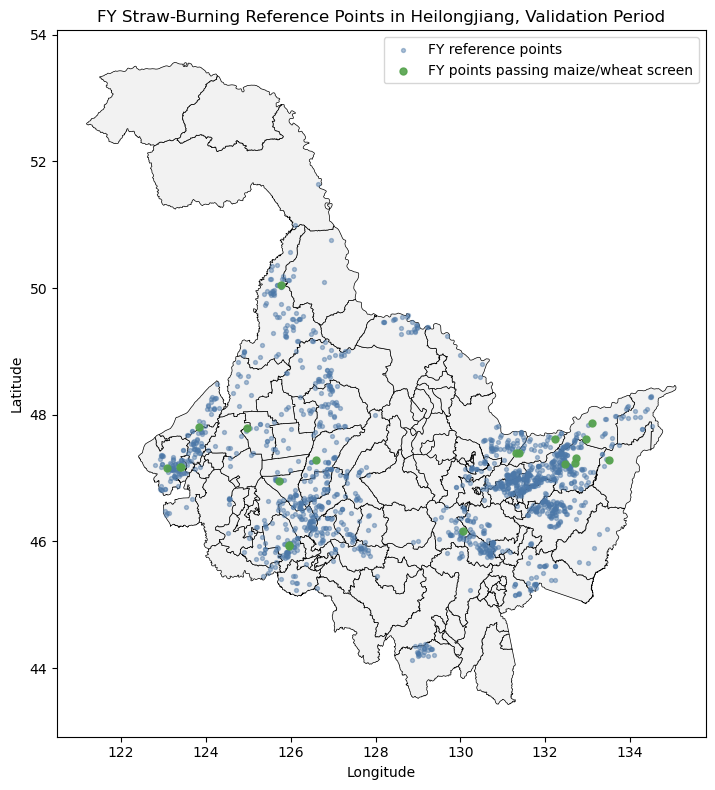

In [296]:
from scipy.spatial import cKDTree

# Match FY and MODIS events using the FY observation period and a narrow space-time window.
FY_VALIDATION_START = pd.Timestamp("2016-08-01")
FY_VALIDATION_END = pd.Timestamp("2017-02-28")
FY_DISTANCE_THRESHOLD_M = 3000
FY_DATE_WINDOW_DAYS = 1
FY_MATCH_CRS = "EPSG:32652"


def load_fy_reference(excel_path):
    """Load the FY straw-burning spreadsheet and standardise key fields."""
    fy_raw = pd.read_excel(excel_path)
    if fy_raw.shape[1] < 3:
        raise ValueError("The FY spreadsheet must contain date, longitude and latitude columns.")

    # The source column names may appear with encoding issues, so use column positions.
    fy = fy_raw.iloc[:, :6].copy()
    fy.columns = ["fy_date", "longitude", "latitude", "province", "city", "county"][: fy.shape[1]]
    fy["fy_date"] = pd.to_datetime(fy["fy_date"], errors="coerce")
    fy["longitude"] = pd.to_numeric(fy["longitude"], errors="coerce")
    fy["latitude"] = pd.to_numeric(fy["latitude"], errors="coerce")
    fy = fy.dropna(subset=["fy_date", "longitude", "latitude"]).copy()
    return gpd.GeoDataFrame(
        fy,
        geometry=gpd.points_from_xy(fy["longitude"], fy["latitude"]),
        crs="EPSG:4326",
    )


def filter_fy_to_heilongjiang(fy_gdf):
    """Filter FY points to the study region using the county boundary when available."""
    if hlj_boundary is not None:
        fy_hlj_local = gpd.sjoin(fy_gdf, hlj_boundary, how="inner", predicate="intersects")
        fy_hlj_local = fy_hlj_local.drop(columns=[col for col in ["index_right"] if col in fy_hlj_local.columns])
        return fy_hlj_local.reset_index(drop=True)

    minx, miny, maxx, maxy = modis_hlj.total_bounds
    return fy_gdf.cx[minx:maxx, miny:maxy].reset_index(drop=True)


def add_fy_crop_context(fy_hlj_local):
    """Sample maize and wheat maturity rasters at FY straw-burning locations."""
    fy_hlj_local = fy_hlj_local.copy()
    fy_hlj_local["year"] = fy_hlj_local["fy_date"].dt.year
    fy_hlj_local["maize_mature_doy"] = np.nan
    fy_hlj_local["wheat_mature_doy"] = np.nan

    for year in sorted(fy_hlj_local["year"].dropna().unique()):
        year_mask = fy_hlj_local["year"] == year
        fy_this_year = fy_hlj_local.loc[year_mask]
        maize_path = crop_raster_path("Maize", year)
        wheat_path = crop_raster_path("Wheat", year)

        if maize_path.exists():
            fy_hlj_local.loc[year_mask, "maize_mature_doy"] = clean_maturity_doy(
                pd.Series(get_crop_mature_doy(fy_this_year, maize_path), index=fy_this_year.index)
            )
        if wheat_path.exists():
            fy_hlj_local.loc[year_mask, "wheat_mature_doy"] = clean_maturity_doy(
                pd.Series(get_crop_mature_doy(fy_this_year, wheat_path), index=fy_this_year.index)
            )

    fy_hlj_local["in_maize_after"] = fy_hlj_local.apply(
        lambda row: is_after_maturity(row["fy_date"], row["maize_mature_doy"]), axis=1
    )
    fy_hlj_local["in_wheat_after"] = fy_hlj_local.apply(
        lambda row: is_after_maturity(row["fy_date"], row["wheat_mature_doy"]), axis=1
    )
    fy_hlj_local["in_crop_maturity_surface"] = (
        fy_hlj_local["maize_mature_doy"].notna() | fy_hlj_local["wheat_mature_doy"].notna()
    )
    fy_hlj_local["fy_post_maturity_screened"] = (
        fy_hlj_local["in_maize_after"] | fy_hlj_local["in_wheat_after"]
    )
    return fy_hlj_local


def match_fy_to_modis(fy_hlj_local, modis_hlj_local, screening_mask):
    """Match each FY point to the nearest MODIS fire within a date and distance window."""
    modis_match = modis_hlj_local.copy().reset_index(drop=False).rename(columns={"index": "modis_index"})
    modis_match["is_agri_screened"] = modis_match["modis_index"].map(screening_mask).fillna(False).astype(bool)
    modis_match["in_crop_maturity_surface"] = (
        modis_match["maize_mature_doy"].notna() | modis_match["wheat_mature_doy"].notna()
    )
    modis_projected = modis_match.to_crs(FY_MATCH_CRS)
    fy_projected = fy_hlj_local.to_crs(FY_MATCH_CRS)

    match_rows = []
    for fy_idx, fy_row in fy_projected.iterrows():
        date_min = fy_row["fy_date"] - pd.Timedelta(days=FY_DATE_WINDOW_DAYS)
        date_max = fy_row["fy_date"] + pd.Timedelta(days=FY_DATE_WINDOW_DAYS)
        candidates = modis_projected[
            (modis_projected["acq_date"] >= date_min) &
            (modis_projected["acq_date"] <= date_max)
        ]

        if candidates.empty:
            match_rows.append({"fy_index": fy_idx, "matched": False})
            continue

        candidate_coords = np.column_stack([candidates.geometry.x, candidates.geometry.y])
        tree = cKDTree(candidate_coords)
        distance_m, nearest_position = tree.query([fy_row.geometry.x, fy_row.geometry.y], k=1)
        nearest = candidates.iloc[nearest_position]

        if distance_m <= FY_DISTANCE_THRESHOLD_M:
            match_rows.append({
                "fy_index": fy_idx,
                "matched": True,
                "modis_index": nearest["modis_index"],
                "distance_m": distance_m,
                "modis_date": nearest["acq_date"],
                "matched_agri_screened": bool(nearest["is_agri_screened"]),
                "matched_crop_surface": bool(nearest["in_crop_maturity_surface"]),
            })
        else:
            match_rows.append({"fy_index": fy_idx, "matched": False, "distance_m": distance_m})

    return pd.DataFrame(match_rows)


FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Build the FY validation dataset and compare it with MODIS detections from the same period.
fy_gdf = load_fy_reference(fy_excel_path)
fy_gdf = fy_gdf[(fy_gdf["fy_date"] >= FY_VALIDATION_START) & (fy_gdf["fy_date"] <= FY_VALIDATION_END)].copy()
fy_hlj = add_fy_crop_context(filter_fy_to_heilongjiang(fy_gdf))

modis_hlj_fy_period = modis_hlj[
    (modis_hlj["acq_date"] >= FY_VALIDATION_START) &
    (modis_hlj["acq_date"] <= FY_VALIDATION_END)
].copy()
fy_match_df = match_fy_to_modis(fy_hlj, modis_hlj_fy_period, post_maturity_mask)
fy_matched = fy_match_df[fy_match_df["matched"]].copy()

fy_source_count = len(fy_gdf)
fy_hlj_count = len(fy_hlj)
fy_matched_count = int(fy_match_df["matched"].sum())
fy_matched_agri_count = int(fy_matched["matched_agri_screened"].sum()) if not fy_matched.empty else 0
fy_crop_surface_count = int(fy_hlj["in_crop_maturity_surface"].sum())
fy_post_maturity_count = int(fy_hlj["fy_post_maturity_screened"].sum())

# Report both counts and proportions so validation strength is easier to interpret.
fy_validation_summary = pd.DataFrame({
    "Metric": [
        "FY reference points in validation period",
        "FY reference points in Heilongjiang",
        "FY points matched to same-period MODIS within 3 km and +/-1 day",
        "Matched FY points linked to current maize/wheat post-maturity screen",
        "FY points directly on valid maize/wheat maturity pixels",
        "FY points directly passing maize/wheat post-maturity screen",
    ],
    "Count": [
        fy_source_count,
        fy_hlj_count,
        fy_matched_count,
        fy_matched_agri_count,
        fy_crop_surface_count,
        fy_post_maturity_count,
    ],
    "Reference group": [
        "FY validation-period points",
        "All FY points",
        "FY points in Heilongjiang",
        "FY-MODIS matched points",
        "FY points in Heilongjiang",
        "FY points in Heilongjiang",
    ],
    "Share (%)": [
        100.0,
        fy_hlj_count / fy_source_count * 100 if fy_source_count else np.nan,
        fy_matched_count / fy_hlj_count * 100 if fy_hlj_count else np.nan,
        fy_matched_agri_count / fy_matched_count * 100 if fy_matched_count else np.nan,
        fy_crop_surface_count / fy_hlj_count * 100 if fy_hlj_count else np.nan,
        fy_post_maturity_count / fy_hlj_count * 100 if fy_hlj_count else np.nan,
    ],
})

fy_validation_summary["Share (%)"] = fy_validation_summary["Share (%)"].round(2)
display(fy_validation_summary)

if not fy_matched.empty:
    print("FY-MODIS matching distance summary, metres")
    print(fy_matched["distance_m"].describe())

fig, ax = plt.subplots(figsize=(10, 5))
summary_plot_df = fy_validation_summary.iloc[1:].copy()
sns.barplot(data=summary_plot_df, x="Share (%)", y="Metric", ax=ax, color="#4C78A8")
ax.set_title("FY Validation Summary, August 2016-February 2017")
ax.set_xlabel("Share of reference group (%)")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "fy_validation_summary.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
if hlj_boundary is not None:
    hlj_boundary.plot(ax=ax, color="#F2F2F2", edgecolor="black", linewidth=0.5, zorder=1)
fy_hlj.plot(ax=ax, color="#4C78A8", markersize=8, alpha=0.45, label="FY reference points", zorder=2)
fy_screened = fy_hlj[fy_hlj["fy_post_maturity_screened"]]
if not fy_screened.empty:
    fy_screened.plot(ax=ax, color="#54A24B", markersize=25, alpha=0.9, label="FY points passing maize/wheat screen", zorder=3)
ax.set_title("FY Straw-Burning Reference Points in Heilongjiang, Validation Period")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(loc="upper right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "fy_reference_points_map.png", dpi=200, bbox_inches="tight")
plt.show()


The FY validation is now restricted to the same period covered by the reference data: August 2016 to February 2017. In this window, the FY data provide a useful reality check for the satellite fire detections. In the full run, 1,497 of 2,583 FY straw-burning points fall inside Heilongjiang, or 57.96% of the validation-period FY file. Of the Heilongjiang FY points, 1,493 can be matched to a same-period MODIS fire detection within 3 km and within +/-1 day, giving a MODIS matching rate of 99.73%. The median nearest-neighbour distance is about 39 m. This confirms that MODIS captures nearly all FY-observed straw-burning events in the validation period.

The crop-maturity screen has much lower coverage. Only 19 matched FY points are also selected by the current maize/wheat post-maturity screening rule, equal to 1.27% of FY-MODIS matched points. Directly sampling the FY points against the 2016 and 2017 maize and wheat maturity rasters gives a similar result: 540 FY points fall on valid maize or wheat maturity pixels, or 36.07% of Heilongjiang FY points, but only 20 pass the 30-day post-maturity rule, or 1.34%. This validation therefore shows high MODIS-FY event agreement but low recall for the current maize/wheat post-maturity screen. The screened subset should be interpreted as a lower-bound indicator, not a comprehensive straw-burning detector.


## 8. Post-Maturity Window Sensitivity

The 30-day post-maturity window is a modelling choice. To test whether the low FY validation recall is mainly caused by this fixed window, the validation is repeated with 15, 30, 45, 60 and 90-day windows. The FY-MODIS matching step remains unchanged: FY points are still matched to same-period MODIS detections within 3 km and within +/-1 day.

This sensitivity check is also supported by wider literature on biomass open burning. Zhou et al. (2021) show that MODIS active-fire data provide fire timing, location and FRP, but Terra and Aqua provide only four MODIS FRP observations per day, so short-lived fire activity may be missed. They also report that Heilongjiang's 2018 crop-straw composition included a large rice-straw component alongside maize straw, while wheat straw contributed only a very small share. This supports the interpretation that low recall may reflect crop-scope limitations, not only the length of the post-maturity window.


,Window days,FY in Heilongjiang,FY matched to same-period MODIS,Matched MODIS passing screen,Matched recall (%),FY on valid maize/wheat maturity pixels,FY directly passing screen,Direct FY recall (%)
0,15,1497,1493,1,0.07,540,1,0.07
1,30,1497,1493,19,1.27,540,20,1.34
2,45,1497,1493,255,17.08,540,253,16.90
3,60,1497,1493,504,33.76,540,504,33.67
4,90,1497,1493,532,35.63,540,530,35.40


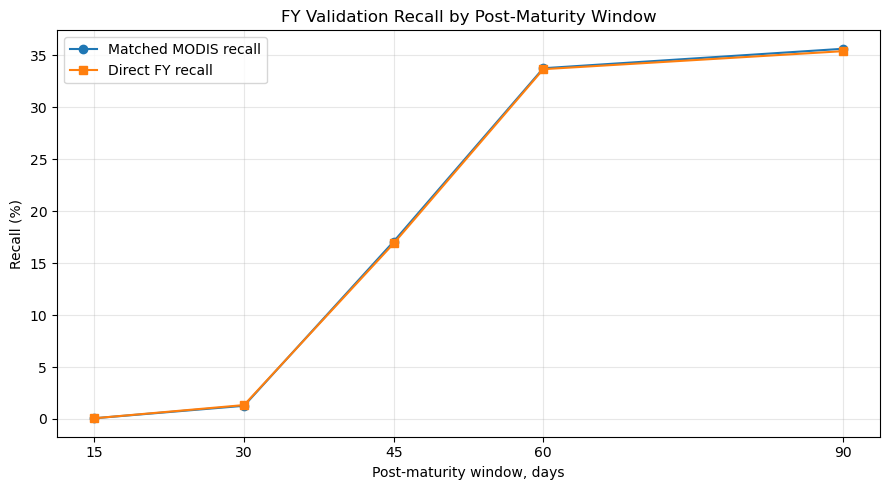

In [299]:
SENSITIVITY_WINDOWS = [15, 30, 45, 60, 90]


def post_maturity_screen_for_window(point_df, date_column, window_days):
    """Return post-maturity flags for a chosen maturity-window length."""
    maize_after = point_df.apply(
        lambda row: is_after_maturity(row[date_column], row["maize_mature_doy"], window_days),
        axis=1,
    )
    wheat_after = point_df.apply(
        lambda row: is_after_maturity(row[date_column], row["wheat_mature_doy"], window_days),
        axis=1,
    )
    return maize_after | wheat_after


# Reconstruct matched same-period MODIS records for sensitivity testing.
fy_matched_detail = fy_match_df[fy_match_df["matched"]].merge(
    modis_hlj_fy_period[["acq_date", "maize_mature_doy", "wheat_mature_doy"]],
    left_on="modis_index",
    right_index=True,
    how="left",
)

sensitivity_rows = []
for window_days in SENSITIVITY_WINDOWS:
    direct_fy_flags = post_maturity_screen_for_window(fy_hlj, "fy_date", window_days)
    matched_modis_flags = post_maturity_screen_for_window(fy_matched_detail, "acq_date", window_days)

    sensitivity_rows.append({
        "Window days": window_days,
        "FY in Heilongjiang": len(fy_hlj),
        "FY matched to same-period MODIS": len(fy_matched_detail),
        "Matched MODIS passing screen": int(matched_modis_flags.sum()),
        "Matched recall (%)": round(matched_modis_flags.mean() * 100, 2),
        "FY on valid maize/wheat maturity pixels": int(fy_hlj["in_crop_maturity_surface"].sum()),
        "FY directly passing screen": int(direct_fy_flags.sum()),
        "Direct FY recall (%)": round(direct_fy_flags.mean() * 100, 2),
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
display(sensitivity_df)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sensitivity_df["Window days"], sensitivity_df["Matched recall (%)"], marker="o", label="Matched MODIS recall")
ax.plot(sensitivity_df["Window days"], sensitivity_df["Direct FY recall (%)"], marker="s", label="Direct FY recall")
ax.set_title("FY Validation Recall by Post-Maturity Window")
ax.set_xlabel("Post-maturity window, days")
ax.set_ylabel("Recall (%)")
ax.set_xticks(SENSITIVITY_WINDOWS)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "fy_window_sensitivity.png", dpi=200, bbox_inches="tight")
plt.show()


The sensitivity table shows that recall increases as the post-maturity window is extended. This means the 30-day window is one reason for the low FY validation recall. However, the recall remains limited even when the window is extended to 90 days: the matched-MODIS recall rises to 35.63%, and the direct FY recall rises to 35.40%. Therefore, the low recall cannot be explained by the 30-day window alone.

The remaining gap is consistent with the crop-scope limitation. Zhou et al. (2021) report that Heilongjiang's crop straw was composed of 41.0% rice straw, 0.7% wheat straw and 58.3% maize straw in 2018. Because this notebook only uses maize and wheat maturity rasters, FY straw-burning points linked to rice or other crop residues cannot be selected by the current screen. The sensitivity analysis therefore supports a cautious interpretation: the workflow identifies a lower-bound maize/wheat post-maturity subset, not total straw burning.


## 9. Annual Results

The yearly table checks how many fire detections were selected by the maize/wheat post-maturity screening rule in each year. 


In [302]:
total_fires_per_year = modis_hlj.groupby("year").size()
# Compare annual agricultural-burning detections with all Heilongjiang fires.
harvest_fires_per_year = modis_hlj[post_maturity_mask].groupby("year").size()

verification_df = pd.DataFrame({
    "Total_Fires": total_fires_per_year,
    "Post_Maturity_Fires": harvest_fires_per_year,
}).fillna(0)
verification_df["Ratio (%)"] = (
    verification_df["Post_Maturity_Fires"] / verification_df["Total_Fires"] * 100
)

print("Annual validation table")
verification_df


Annual validation table


,Total_Fires,Post_Maturity_Fires,Ratio (%)
year,,,
2010,12167,631,5.186159
2011,21496,1256,5.842948
2012,9179,67,0.729927
2013,13947,792,5.678641
2014,29127,656,2.252206
2015,33844,93,0.274790
2016,24475,185,0.755873
2017,34833,285,0.818190
2018,11344,56,0.493653


The annual ratios show that the post-maturity screening subset is a small share of all MODIS fire detections, but the share is not constant over time. The highest ratios appear in 2010, 2011 and 2013, each above 5%, while most later years are below 1%. This suggests that the narrow maize/wheat post-maturity subset became less prominent after the early part of the decade.

This pattern should be interpreted carefully. It may reflect changes in burning behaviour, enforcement, crop calendars, satellite detection conditions or data quality. Even so, the year-by-year table is useful because it shows that the classification is not simply selecting a fixed percentage of fires each year.

The following map also uses sampling for the much larger "other fires" class, while retaining all post-maturity maize and wheat detections.


## 10. Spatial Distribution of Classified Fires

The next map separates other fires from maize and wheat post-maturity-screened fires. This helps show whether the screened subset forms visible spatial clusters.


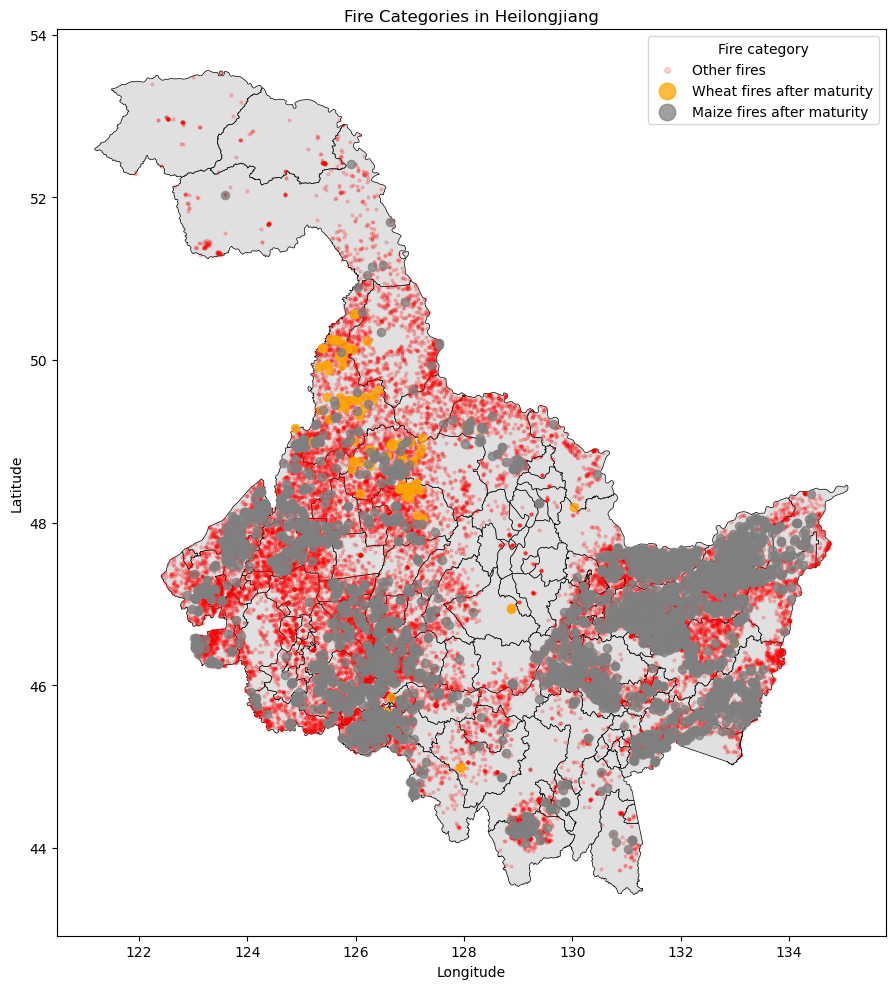

In [305]:
FIRE_OTHER = "Other fires"
FIRE_MAIZE = "Maize fires after maturity"
FIRE_WHEAT = "Wheat fires after maturity"
FIRE_AGRICULTURAL = "Agricultural burning fires"

# Separate mapped points into other fires and the post-maturity screening subset.
modis_hlj["fire_category"] = FIRE_OTHER
modis_hlj.loc[modis_hlj["in_maize_after"], "fire_category"] = FIRE_MAIZE
modis_hlj.loc[modis_hlj["in_wheat_after"], "fire_category"] = FIRE_WHEAT
modis_hlj["fire_category"] = modis_hlj["fire_category"].astype("category")

fig, ax = plt.subplots(figsize=(12, 10))
ax.set_aspect("equal")

if hlj_boundary is not None:
    hlj_boundary.plot(ax=ax, color="#E0E0E0", edgecolor="black", linewidth=0.5, zorder=1)

other_fires = modis_hlj[modis_hlj["fire_category"] == FIRE_OTHER]
if len(other_fires) > PLOT_SAMPLE_SIZE:
    other_fires = other_fires.sample(n=PLOT_SAMPLE_SIZE, random_state=RANDOM_SEED)

plot_specs = [
    (other_fires, FIRE_OTHER, "red", 4, 0.18, 2),
    (modis_hlj[modis_hlj["fire_category"] == FIRE_WHEAT], FIRE_WHEAT, "orange", 35, 0.75, 3),
    (modis_hlj[modis_hlj["fire_category"] == FIRE_MAIZE], FIRE_MAIZE, "grey", 35, 0.75, 4),
]

for subset, label, colour, size, alpha, zorder in plot_specs:
    if not subset.empty:
        subset.plot(ax=ax, color=colour, markersize=size, alpha=alpha, label=label, zorder=zorder)

ax.legend(title="Fire category", loc="upper right", markerscale=2)
ax.set_title("Fire Categories in Heilongjiang")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()


The spatial pattern provides a useful cross-check against the crop-mapping literature. Huang et al. (2026) mapped maize, rice and soybean in Heilongjiang from 2019 to 2023 and showed that the province's main grain crops form clear regional clusters rather than a random surface. The post-maturity fire detections in this notebook should therefore be interpreted as crop-contextual fire events: their location on valid crop-maturity pixels supports the crop-context interpretation, while their separation from many other fires supports the need for a crop-mask step.

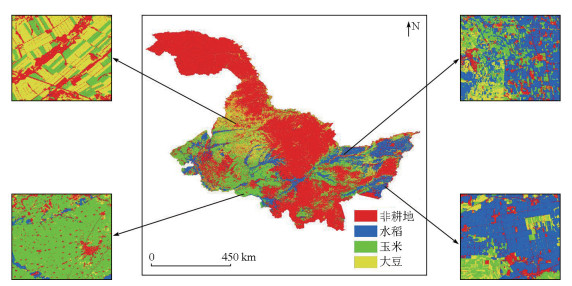
Crop classification results of Heilongjiang Province in 2019 Source: Huang et al. (2026)

This comparison is contextual rather than direct validation. Huang et al. (2026) describe crop distribution after the MODIS study period and include rice and soybean, while this notebook classifies maize and wheat fires from 2010 to 2019. Even so, the paper supports the broader result that grain-crop geography is essential for explaining fire patterns in Heilongjiang.


## 11. Temporal Trends

The trend analysis focuses only on fires selected by the maize/wheat post-maturity screen. A linear trend is fitted when at least two years of data are available.


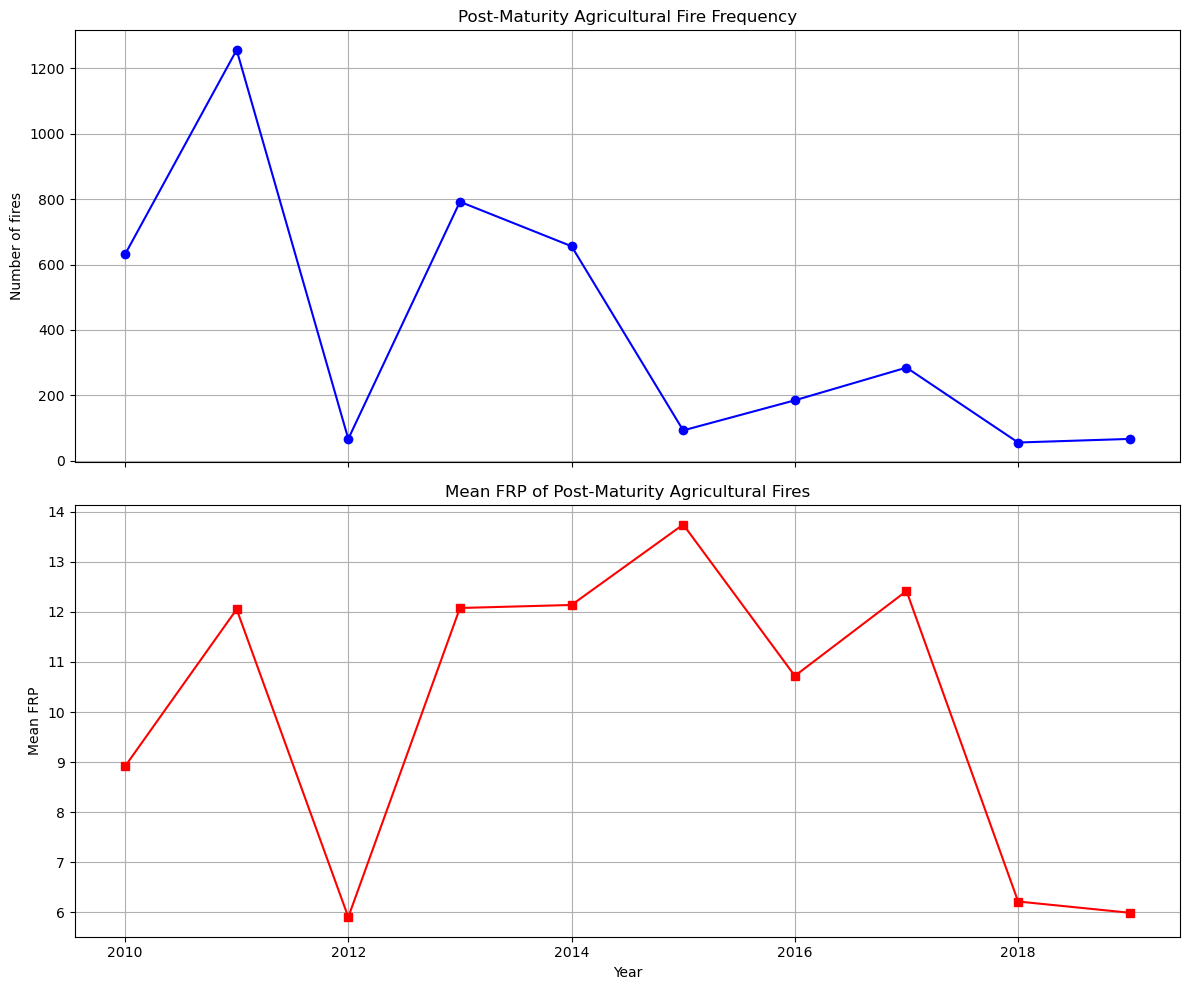

Frequency trend analysis
Slope: -89.52 fires per year
p-value: 0.0362


In [308]:
# Trend analysis uses only the classified agricultural-burning subset.
agri_fires = modis_hlj[post_maturity_mask].copy()
agri_fires["year"] = agri_fires["acq_date"].dt.year

trends_df = agri_fires.groupby("year").agg(
    Frequency=("geometry", "size"),
    Mean_FRP=("frp", "mean"),
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
trends_df["Frequency"].plot(ax=ax1, marker="o", color="blue")
ax1.set_title("Post-Maturity Agricultural Fire Frequency")
ax1.set_ylabel("Number of fires")
ax1.grid(True)

trends_df["Mean_FRP"].plot(ax=ax2, marker="s", color="red")
ax2.set_title("Mean FRP of Post-Maturity Agricultural Fires")
ax2.set_ylabel("Mean FRP")
ax2.set_xlabel("Year")
ax2.grid(True)
plt.tight_layout()
plt.show()

if len(trends_df) >= 2:
    slope, intercept, r_value, p_value, std_err = stats.linregress(trends_df.index, trends_df["Frequency"])
    print("Frequency trend analysis")
    print(f"Slope: {slope:.2f} fires per year")
    print(f"p-value: {p_value:.4f}")
else:
    print("Trend analysis skipped because at least two years are required.")


The time series indicates a decline in post-maturity-screened fire detections over the study period. The fitted slope is -89.52 fires per year, with a p-value of 0.0362. This points to a statistically detectable downward trend in the classified agricultural burning subset.

This result should be read as an indicator rather than a final causal claim. Satellite overpass timing, cloud cover, detection thresholds and changes in crop management can all affect the count. However, the trend is consistent with the annual table, where higher classified shares are concentrated in the earlier years.


## 12. Comparing Agricultural and Other Fires

Finally, agricultural-burning detections are compared with other fires using FRP, hour of detection and month. These comparisons show whether the classified fires have a distinct intensity or timing pattern.


FRP summary by fire type
                               count       mean        std  min  25%   50%  \
Fire_Type                                                                    
Agricultural burning fires    4088.0  11.310421  13.761724  2.5  5.0   7.1   
Other fires                 202841.0  19.104751  27.533375  0.0  6.9  11.0   

                             75%     max  
Fire_Type                                 
Agricultural burning fires  12.5   315.4  
Other fires                 20.7  1824.4  
FRP t-test p-value: 0.0000


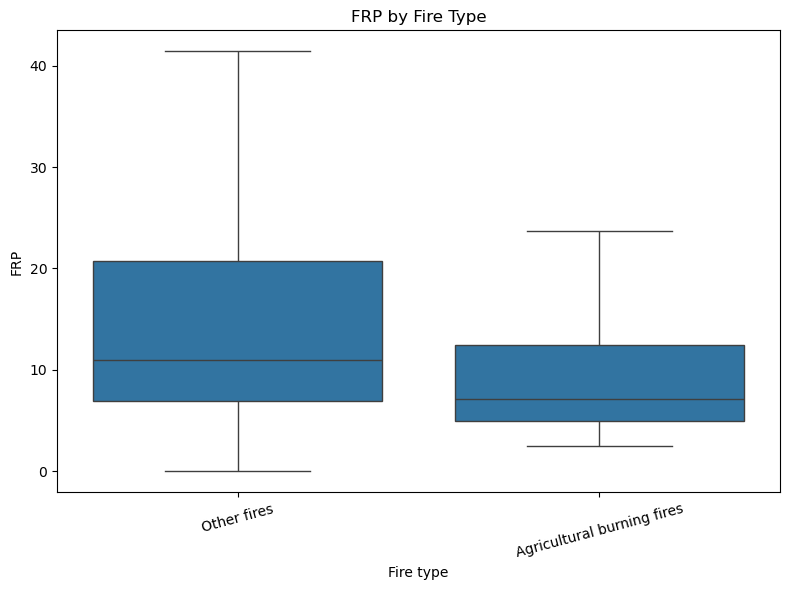

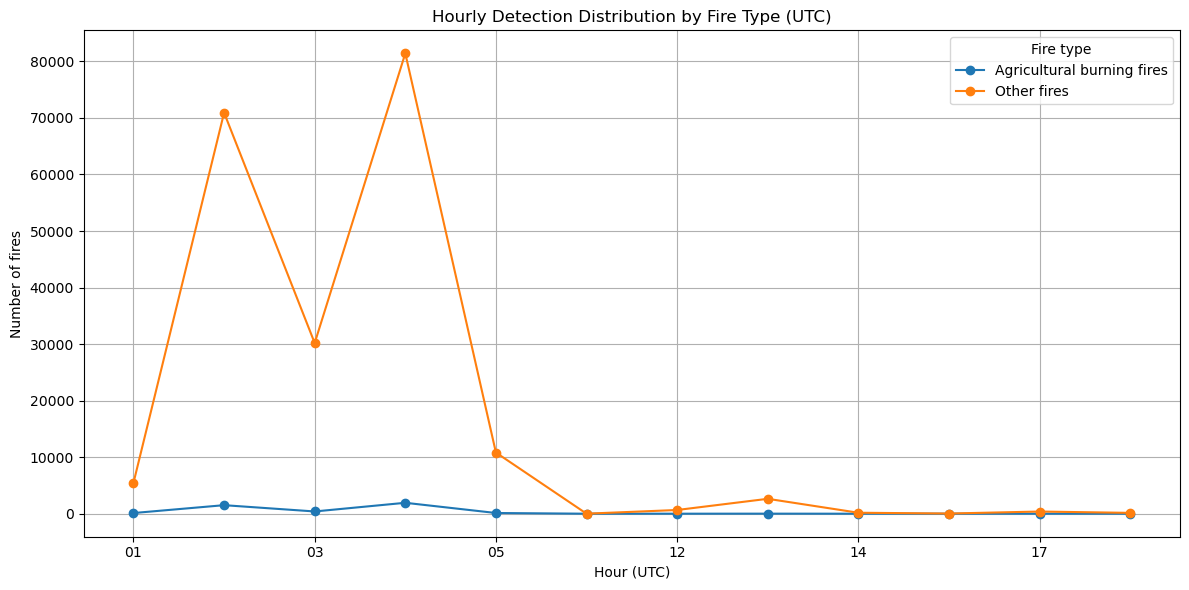

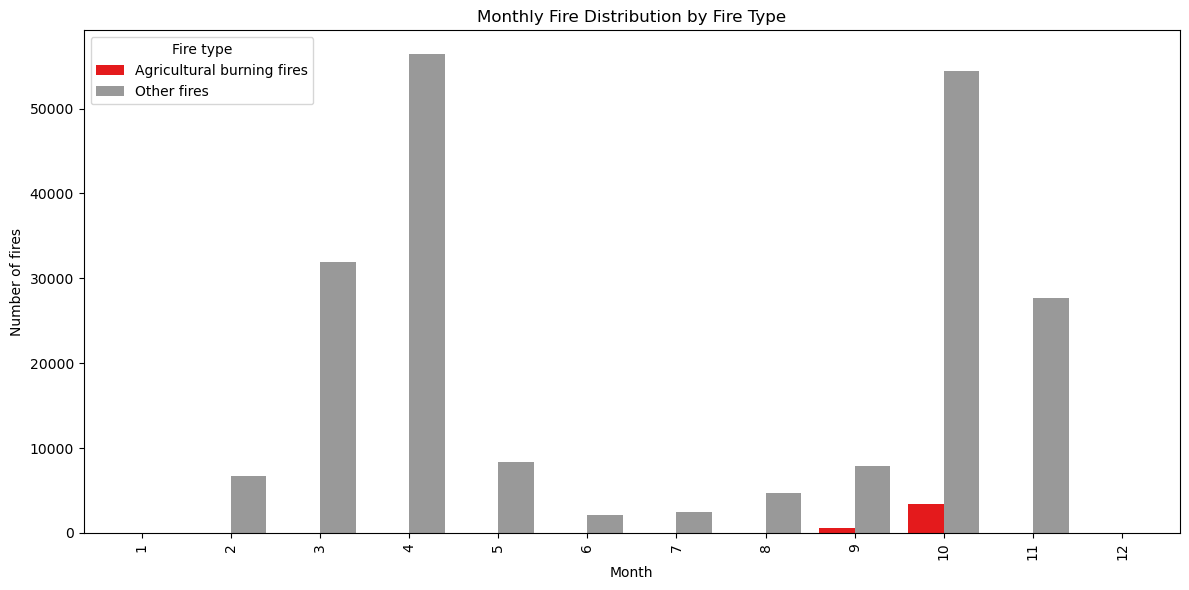

In [339]:
# Compare intensity and timing between the screened subset and other fires.
modis_hlj["Fire_Type"] = np.where(post_maturity_mask, FIRE_AGRICULTURAL, FIRE_OTHER)

frp_stats = modis_hlj.groupby("Fire_Type")["frp"].describe()
print("FRP summary by fire type")
print(frp_stats)

agri_frp = modis_hlj.loc[modis_hlj["Fire_Type"] == FIRE_AGRICULTURAL, "frp"].dropna()
other_frp = modis_hlj.loc[modis_hlj["Fire_Type"] == FIRE_OTHER, "frp"].dropna()

# Welch's t-test is used because the two groups have different sample sizes.
if len(agri_frp) > 1 and len(other_frp) > 1:
    t_stat, p_value = stats.ttest_ind(agri_frp, other_frp, equal_var=False)
    print(f"FRP t-test p-value: {p_value:.4f}")
else:
    print("FRP t-test skipped because both groups need at least two observations.")

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=modis_hlj, x="Fire_Type", y="frp", showfliers=False, ax=ax)
ax.set_title("FRP by Fire Type")
ax.set_xlabel("Fire type")
ax.set_ylabel("FRP")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

modis_hlj["hour_utc"] = modis_hlj["acq_time"].astype(str).str.zfill(4).str[:2]
hourly_comparison = modis_hlj.groupby(["hour_utc", "Fire_Type"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
hourly_comparison.plot(kind="line", marker="o", ax=ax)
ax.set_title("Hourly Detection Distribution by Fire Type (UTC)")
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Number of fires")
ax.grid(True)
ax.legend(title="Fire type")
plt.tight_layout()
plt.show()

monthly_comparison = modis_hlj.groupby(["month", "Fire_Type"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
monthly_comparison.plot(kind="bar", ax=ax, width=0.8, cmap="Set1")
ax.set_title("Monthly Fire Distribution by Fire Type")
ax.set_xlabel("Month")
ax.set_ylabel("Number of fires")
ax.legend(title="Fire type")
plt.tight_layout()
plt.show()


The FRP comparison shows that the screened agricultural burning fires are generally weaker than the remaining fire detections. Their mean FRP is 11.31 MW, lower than 19.10 MW for other fires, and their median FRP is also lower, 7.1 MW compared with 11.0 MW. The interquartile range is narrower for agricultural burning fires, suggesting that most selected crop-residue burning events are relatively low-intensity fires. The t-test result is statistically significant, indicating that the FRP difference between the two groups is unlikely to be due to random variation alone. However, this should be interpreted with caution because the two groups are highly unbalanced in size, and “other fires” may include many different fire sources rather than one single fire type.

## 13. Conclusion

This notebook identifies a narrow subset of MODIS fire detections that fall on valid maize or wheat maturity pixels and occur shortly after mapped crop maturity. In the full boundary-filtered run, Heilongjiang contains 206,929 MODIS fire detections from 2010 to 2019, and 4,088 are selected by the post-maturity screening rule. This should not be interpreted as a comprehensive agricultural-burning detector; it is a rule-based lower-bound screen.

The FY-satellite validation during August 2016-February 2017 strengthens and qualifies this result. Most FY straw-burning reference points in Heilongjiang can be matched to same-period MODIS detections within a narrow space-time window, confirming that the satellite fire data capture many observed straw-burning events. The window sensitivity analysis shows that extending the post-maturity window increases recall, but recall remains limited even at 90 days. This suggests that the low recall is caused by both the window definition and the limited crop scope of the current maize/wheat screen.

The post-maturity-screened fires have lower fire radiative power than other fires on average. Their mean FRP is 11.31, compared with 19.10 for other fires, and the t-test gives a p-value below 0.001. This suggests that the agricultural-burning subset is not only temporally distinct, but also tends to be less intense than the broader set of fire detections.

There are several limitations. MODIS detects active fires only at satellite overpass times, so short-lived, night-time or cloud-obscured fires may be missed. The 30-day post-maturity window is a rule-based assumption, not direct proof of burning cause. Crop maturity rasters and county boundaries may also contain spatial or temporal uncertainty. The Fengyun straw-burning reference data cover only August 2016 to February 2017 and do not identify crop type, so they are useful for validation but not for crop-specific attribution. Huang et al. (2026) also show that rice and soybean are important parts of Heilongjiang's grain-crop landscape, while this notebook only classifies post-maturity fires in maize and wheat areas. Future work should test whether adding rice and soybean crop masks changes the estimated agricultural-burning share. Finally, the analysis identifies likely agricultural burning events, but it does not validate them against field observations, enforcement records, high-resolution imagery or local meteorological and pollution measurements.

Overall, the workflow provides a reproducible narrow screening method rather than a definitive attribution model or comprehensive agricultural-burning detector. It is suitable for exploratory spatial and temporal analysis. Future work could compare MODIS with another fire product, test different post-maturity windows, add uncertainty checks and validate selected detections against land-use, policy or local field records.


## References

Huang, J., Wu, H., Zhang, X., Huang, J., Cheng, Y. and Wen, F. (2026). Mapping and spatiotemporal evolution of main grain crops in Heilongjiang Province from 2019 to 2023 based on spectral and temporal feature screening. *Remote Sensing for Natural Resources*, 38(1), 260-270. https://doi.org/10.6046/zrzyyg.2025024

Zhou, Y., Liao, W., Yang, J., Huang, X. and Chen, C. (2021). Based on MODIS fire pixel location data to characterize the biomass burning and air pollutants emissions in northern and southern China. *Acta Scientiae Circumstantiae*, 41(9), 3696-3708. https://html.rhhz.net/hjkxxb/html/20200823001.htm
